In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [2]:
df = pd.read_csv("data/clean/lyrics.csv")

In [3]:
v = TfidfVectorizer(
    stop_words = "english",
    max_features = 5500 
)

X = v.fit_transform(df["lyrics_clean"])

v.get_feature_names_out()

array(['10', '100', '1962', ..., 'zipped', 'zone', 'zoo'],
      shape=(3976,), dtype=object)

22 songs, 3859 features

In [4]:
X.shape

(225, 3976)

In [5]:
tfidf = pd.DataFrame(X.toarray(), columns = v.get_feature_names_out())

tfidf.head()

,10,100,1962,1993,20th,22,405,409,45,51,...,youre,yourе,youth,youthful,youths,youve,zeros,zipped,zone,zoo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.083580,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.046443,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.023468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
y = df["band_name"] # outcome variable
X = df["lyrics_clean"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, shuffle = True, stratify = y
)

In [8]:
X_train_tfidf = v.fit_transform(X_train)

X_test_tfidf = v.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [10]:
from sklearn.metrics import classification_report

preds = model.predict(X_test_tfidf)

print(classification_report(y_test, preds))

                     precision    recall  f1-score   support

   Benjamin Gibbard       1.00      0.25      0.40         8
Death Cab for Cutie       0.76      0.97      0.85        33
 The Postal Service       0.00      0.00      0.00         4

           accuracy                           0.76        45
          macro avg       0.59      0.41      0.42        45
       weighted avg       0.74      0.76      0.70        45



In [11]:
import wordcloud

In [12]:
from sklearn.decomposition import PCA

X = v.fit_transform(df["lyrics_clean"]) 

X_dense = X.toarray()

pca = PCA(n_components=2)

X_2d = pca.fit_transform(X_dense)

df["x"] = X_2d[:, 0]
df["y"] = X_2d[:,1]


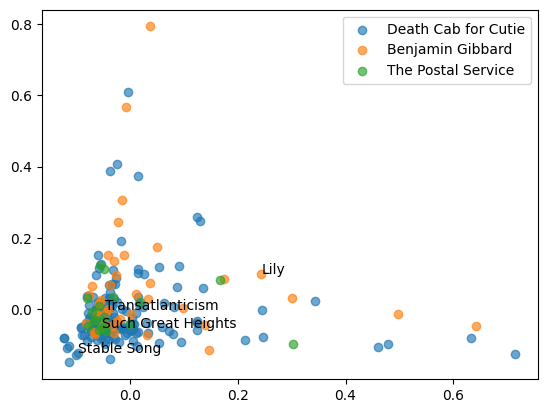

In [13]:
import matplotlib.pyplot as plt 

artists = df["band_name"].unique()

for artist in artists:
    subset = df[df["band_name"] == artist]
    plt.scatter(subset["x"], subset["y"], 
                label=artist, alpha = 0.65)

favs = ["Stable Song", 
        "Transatlanticism", 
        "Lily", # biased toward this one :) 
        "Such Great Heights"]

for i, row in df.iterrows():
    if row["song_name"] in favs:
        plt.annotate(
            row["song_name"],
            (row["x"], row["y"]),
            fontsize = 10
        )

plt.legend()
plt.show()

In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["lyrics_clean"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

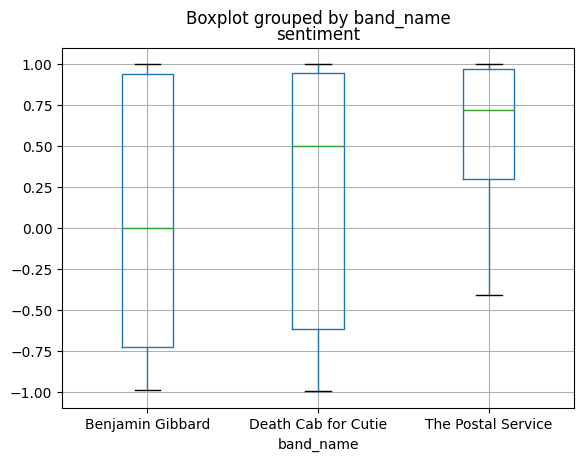

In [15]:
df.boxplot(column="sentiment", by = "band_name")
plt.show()

<Axes: xlabel='album'>

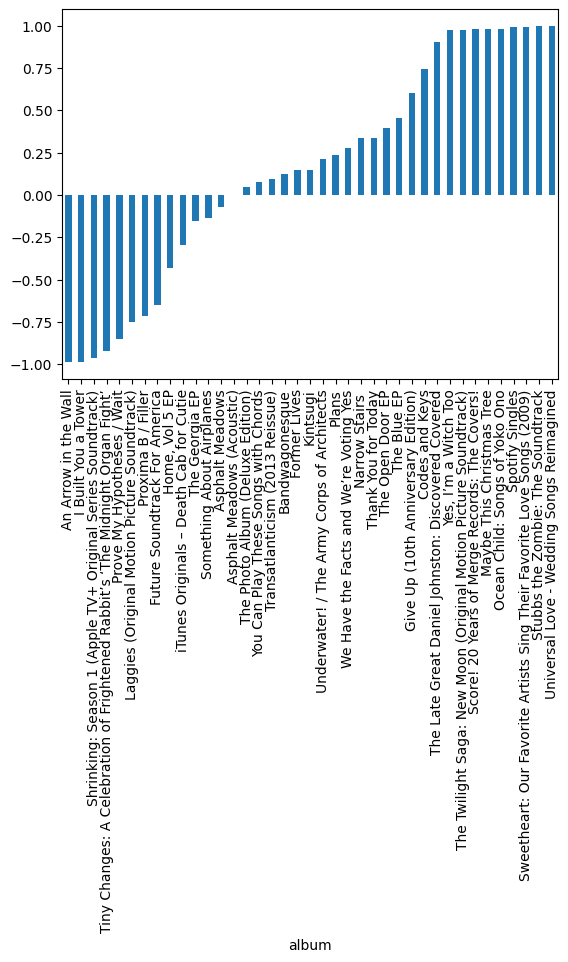

In [16]:
df.groupby("album")["sentiment"].mean().sort_values().plot(kind="bar")

In [17]:
df.sort_values("sentiment").head(5)[["song_name", "sentiment"]]

,song_name,sentiment
178,Company Calls,-0.9974
71,Good Help (Is So Hard to Find),-0.9943
67,You Remind Me Of Home,-0.9895
139,Flirted With You All My Life,-0.9879
68,Full of Stars,-0.9877


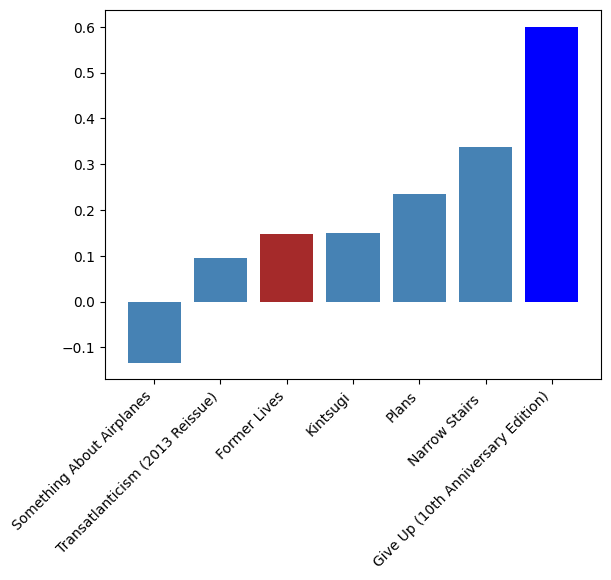

In [19]:
fav_albums = [
    "Plans",
    "Transatlanticism (2013 Reissue)",
    "Narrow Stairs ",
    "Kintsugi",
    "Give Up (10th Anniversary Edition)",
    "Former Lives",
    "Something About Airplanes",
    ""
]

col_map = { 
    "Death Cab for Cutie": "steelblue",
    "Benjamin Gibbard": "brown",
    "The Postal Service": "blue"}

subset = df[df["album"].isin(fav_albums)]

sentiment_album = (
    subset.groupby(["band_name", "album"], as_index = False)["sentiment"]
    .mean()
)

sentiment_album["color"] = sentiment_album["band_name"].map(col_map)

plot_df = sentiment_album.sort_values("sentiment")
plt.bar(
    plot_df["album"],
    plot_df["sentiment"],
    color=plot_df["color"]
)
plt.xticks(rotation=45, ha = "right")
plt.show()